# Engenharia de Features e Modelagem Preditiva

Nesta fase do projeto, nosso objetivo é enriquecer nosso dataset com novas features (engenharia de features) que possam conter sinais preditivos. Após a criação dessas features, faremos uma avaliação robusta de diversos modelos de machine learning para encontrar o que melhor se adapta ao problema de prever a direção do mercado.

In [ ]:
import pandas as pd

In [ ]:
df = pd.read_csv('01.limpeza_e_padronização.csv')
df.head()

,Data,Último,Abertura,Máxima,Mínima,Vol.,Var%
0,2005-01-17,24.515,24.924,25.022,24.515,75060000.0,-1.64
1,2005-01-18,24.089,24.515,24.515,24.019,179420000.0,-1.74
2,2005-01-19,24.271,24.091,24.465,24.091,113110000.0,0.76
3,2005-01-20,23.610,24.271,24.271,23.534,182060000.0,-2.72
4,2005-01-21,23.818,23.618,24.006,23.609,97400000.0,0.88


In [ ]:
# Converte a coluna 'DATA' para o tipo datetime
df['Data'] = pd.to_datetime(df['Data'])
# Ordenar o DataFrame
df.sort_values(by='Data', inplace=True)
# Definir 'Data' como o índice
df.set_index('Data', inplace=True)
df.head()

,Último,Abertura,Máxima,Mínima,Vol.,Var%
Data,,,,,,
2005-01-17,24.515,24.924,25.022,24.515,75060000.0,-1.64
2005-01-18,24.089,24.515,24.515,24.019,179420000.0,-1.74
2005-01-19,24.271,24.091,24.465,24.091,113110000.0,0.76
2005-01-20,23.610,24.271,24.271,23.534,182060000.0,-2.72
2005-01-21,23.818,23.618,24.006,23.609,97400000.0,0.88


## Criação de Features (Feature Engineering)

A qualidade de um modelo preditivo depende diretamente da qualidade das informações que fornecemos a ele. Nesta seção, vamos criar um conjunto diversificado de features, baseadas em diferentes hipóteses sobre o que move o mercado.

### Features de Tempo e Calendário

Padrões sazonais ou semanais podem existir. Vamos extrair informações diretamente do índice de data.

In [ ]:
!pip install ta --quiet

  Preparing metadata (setup.py) ... done


In [ ]:
import ta

# --- Criação de Features ---

# Features Baseadas em Tempo
df['Ano'] = df.index.year
df['Mes'] = df.index.month
df['Dia_da_semana'] = df.index.dayofweek

# Features de Retorno e Variação de Preço
df['log_retorno'] = np.log(df['Último'] / df['Último'].shift(1))
df['Range_HL'] = (df['Máxima'] - df['Mínima']).shift(1)
df['Range_OC'] = (df['Último'] - df['Abertura']).shift(1)

# Features Baseadas no Volume
df['Anomalia_Vol'] = (df['Vol.'].shift(1) / df['Vol.'].shift(1).rolling(window=21).mean()) - 1
df['Vol_Change_1'] = df['Vol.'].pct_change().shift(1)
df['Vol_Change_7'] = df['Vol.'].pct_change(periods=7).shift(1)

# Features de Tendência (Médias Móveis)
df['SMA_21-63'] = df['Último'].shift(1).rolling(window=21).mean() - df['Último'].shift(1).rolling(window=63).mean()
df['SMA_63-252'] = df['Último'].shift(1).rolling(window=63).mean() - df['Último'].shift(1).rolling(window=252).mean()
df['Dist_SMA_14'] = (df['Último'].shift(1) / df['Último'].shift(1).rolling(window=14).mean()) - 1

# Features de Volatilidade
df['Volatilidade_21d'] = df['log_retorno'].shift(1).rolling(window=21).std()
df['Volatilidade_252d'] = df['log_retorno'].shift(1).rolling(window=252).std()
df['Vol_Rel_21'] = df['Volatilidade_21d'] / df['Volatilidade_252d']
df['Range_Roll_21'] = (df['Máxima'].shift(1).rolling(window=21).max() - df['Mínima'].shift(1).rolling(window=21).min())

# Features de Defasagem (Lags)
for i in range(1, 6):
    df[f'Lag_Retorno_D-{i}'] = df['log_retorno'].shift(i)
for lag in [1, 3, 7]:
    df[f'Lag_Ultimo_{lag}'] = df['Último'].shift(lag)

# Features de Momentum (Curtíssimo Prazo)
df['SMA_3'] = df['log_retorno'].shift(1).rolling(3).mean()
df['SMA_7'] = df['log_retorno'].shift(1).rolling(7).mean()
df['Momentum_3_7'] = df['SMA_3'] - df['SMA_7']
df['Momentum_7_14'] = df['SMA_7'] - df['Último'].shift(1).rolling(14).mean()

# --- NOVO: Adicionando RSI e MACD (evitando data leakage com .shift(1)) ---
print("Criando features RSI e MACD...")
df['RSI'] = ta.momentum.rsi(df['Último'], window=14).shift(1)
macd = ta.trend.MACD(df['Último'])
df['MACD'] = macd.macd().shift(1)
df['MACD_Signal'] = macd.macd_signal().shift(1)
df['MACD_Diff'] = (df['MACD'] - df['MACD_Signal']).shift(1)
# --- Criação da Variável Alvo ---
print("Criando a variável alvo...")
df['alvo'] = (df['Último'].shift(-1) > df['Último']).astype(int)

# --- Limpeza Final e Salvamento ---
print("Limpando valores NaN e salvando o DataFrame final...")
df_final = df.dropna()
output_filename = '03.dados_classificacao_com_features.csv'
df_final.to_csv(output_filename)
print(f"✅ DataFrame para classificação salvo com sucesso em: '{output_filename}'")


Criando features RSI e MACD...
Criando a variável alvo...
Limpando valores NaN e salvando o DataFrame final...
✅ DataFrame para classificação salvo com sucesso em: '03.dados_classificacao_com_features.csv'


In [ ]:
import pandas as pd
import numpy as np
from xgboost import XGBClassifier
import matplotlib.pyplot as plt
import seaborn as sns

try:
    df_final = pd.read_csv('03.dados_classificacao_com_features.csv', index_col='Data', parse_dates=True)
    print("DataFrame com features carregado com sucesso.")
except FileNotFoundError:
    print("ERRO: Arquivo '03.dados_classificacao_com_features.csv' não encontrado.")
    exit()

print(df_final)

DataFrame com features carregado com sucesso.
             Último  Abertura   Máxima   Mínima          Vol.  Var%   Ano  \
Data                                                                        
2006-01-20   36.695    36.857   36.938   36.432  1.248400e+08 -0.44  2006   
2006-01-23   36.632    36.687   36.771   36.213  1.045700e+08 -0.17  2006   
2006-01-24   37.400    36.632   37.428   36.632  1.088300e+08  2.10  2006   
2006-01-26   38.014    37.402   38.031   37.402  1.682700e+08  1.64  2006   
2006-01-27   37.822    38.018   38.804   37.688  1.468200e+08 -0.51  2006   
...             ...       ...      ...      ...           ...   ...   ...   
2025-03-19  132.508   131.476  132.984  131.451  1.220000e+10  0.79  2025   
2025-03-20  131.955   132.505  132.713  131.813  1.419000e+10 -0.42  2025   
2025-03-21  132.345   132.005  132.588  131.776  1.419000e+10  0.30  2025   
2025-03-24  131.321   132.344  132.424  130.992  8.300000e+09 -0.77  2025   
2025-03-25  132.068   131.327 

# Dicionário de Features Criadas

Nesta seção, detalhamos cada uma das features desenvolvidas para enriquecer o nosso modelo. O objetivo da engenharia de features é transformar os dados brutos de mercado em sinais mais claros e interpretáveis, que possam ser utilizados por um algoritmo de machine learning para encontrar padrões preditivos.

Todas as features foram construídas utilizando a técnica de `shift(1)` para garantir que, em qualquer dia `D`, estamos utilizando apenas informações disponíveis até o final do dia `D-1`. Isso é crucial para evitar o **data leakage** (vazamento de dados) e garantir a robustez do modelo.

---

###  Features Baseadas em Tempo

**Hipótese:** O comportamento do mercado pode ter padrões sazonais ou semanais.

* `Ano`: O ano da observação.
* `Mes`: O mês da observação (1 a 12).
* `Dia_da_semana`: O dia da semana, representado numericamente (Segunda-feira = 0, Terça-feira = 1, ..., Sexta-feira = 4). Pode capturar anomalias como o "efeito segunda-feira".

---

###  Features de Retorno e Variação de Preço

**Hipótese:** A forma como o preço variou no passado recente contém informação sobre o futuro.

* `log_retorno`: O retorno logarítmico do dia. É uma medida padronizada da variação percentual do preço, muito utilizada em finanças por suas propriedades estatísticas.
* `Range_HL`: A diferença entre o preço máximo e mínimo do dia anterior. Mede a **volatilidade intradiária**. Um range alto indica um dia de grande movimentação.
* `Range_OC`: A diferença entre o preço de fechamento e o de abertura do dia anterior. Mede a **força da tendência intradiária**. Um valor muito positivo indica um dia de forte alta.

---

###  Features Baseadas no Volume

**Hipótese:** O volume de negociação indica a força e a convicção por trás de um movimento de preço.

* `Anomalia_Vol`: Compara o volume do dia anterior com a sua média móvel de 21 dias. Valores positivos indicam um volume de negociação acima do normal, o que pode sinalizar eventos importantes.
* `Vol_Change_1`: A variação percentual do volume em relação ao dia anterior.
* `Vol_Change_7`: A variação percentual do volume em relação a 7 dias atrás.

---

###  Features de Tendência (Médias Móveis)

**Hipótese:** A posição do preço em relação às suas médias históricas pode indicar a tendência principal do ativo.

* `SMA_21-63`: A diferença entre a média móvel curta (21 dias) и a média móvel média (63 dias). Sinaliza a direção da tendência de curto a médio prazo.
* `SMA_63-252`: A diferença entre a média móvel média (63 dias) и a longa (252 dias). Sinaliza a direção da tendência de longo prazo.
* `Dist_SMA_14`: A distância percentual do preço de fechamento do dia anterior em relação à sua média móvel de 14 dias. Mede o quão "esticado" o preço está em relação à sua média recente, sendo útil para estratégias de retorno à média.

---

###  Features de Volatilidade

**Hipótese:** O nível de "agitação" ou risco do mercado (volatilidade) pode influenciar a direção futura dos preços.

* `Volatilidade_21d`: O desvio padrão dos retornos logarítmicos nos últimos 21 dias. É a medida clássica de volatilidade histórica de curto prazo.
* `Volatilidade_252d`: O desvio padrão dos retornos logarítmicos no último ano (252 dias de pregão). Mede a volatilidade de longo prazo.
* `Vol_Rel_21`: A razão entre a volatilidade de curto e longo prazo. Valores acima de 1 indicam que o mercado está mais volátil recentemente do que sua média histórica anual.
* `Range_Roll_21`: A diferença entre o preço mais alto e o mais baixo negociados nos últimos 21 dias. Mede a "banda" de negociação do ativo.

---

###  Features de Defasagem (Lags)

**Hipótese:** A informação mais simples e poderosa sobre o amanhã é o que aconteceu hoje, ontem, etc.

* `Lag_Retorno_D-{i}`: O retorno logarítmico de `i` dias atrás (de 1 a 5 dias).
* `Lag_Ultimo_{lag}`: O preço de fechamento de `lag` dias atrás (1, 3 e 7 dias).

---

###  Features de Momentum (Indicadores Técnicos)

**Hipótese:** Indicadores técnicos podem filtrar o ruído dos preços e fornecer sinais mais claros sobre a força e a direção da tendência.

* `SMA_3`, `SMA_7`: Médias móveis de curtíssimo prazo dos retornos.
* `Momentum_3_7`, `Momentum_7_14`: Diferenças entre as médias de retornos, sinalizando aceleração ou desaceleração do movimento de curtíssimo prazo.
* `RSI` (Índice de Força Relativa): Um dos osciladores de momentum mais populares. Mede a magnitude das recentes mudanças de preço para avaliar condições de **sobrecompra** (valores altos, >70) ou **sobrevenda** (valores baixos, <30).
* `MACD` (Convergência/Divergência de Médias Móveis): Mostra a relação entre duas médias móveis exponenciais. É excelente para capturar a **tendência e o momentum**.
* `MACD_Signal`: Uma média móvel da própria linha MACD. Atua como um "gatilho" para sinais, onde o cruzamento entre a linha MACD e a linha de Sinal pode indicar mudanças de tendência.


Treinando o modelo XGBoost com todas as features para análise de importância...
Modelo treinado com sucesso!

Extraindo e plotando a importância das features...

Gráfico de importância das features salvo como 'feature_importance.png'

--- Ranking das Features Mais Importantes ---
         feature  importance
45  Lag_Ultimo_2    0.028380
15    Vol_SMA_21    0.021277
48  Lag_Ultimo_7    0.020706
3         Mínima    0.020480
2         Máxima    0.019488
..           ...         ...
7            Mes    0.011990
5           Var%    0.011859
8      Trimestre    0.000000
20  Anomalia_Vol    0.000000
44  Lag_Ultimo_1    0.000000

[65 rows x 2 columns]


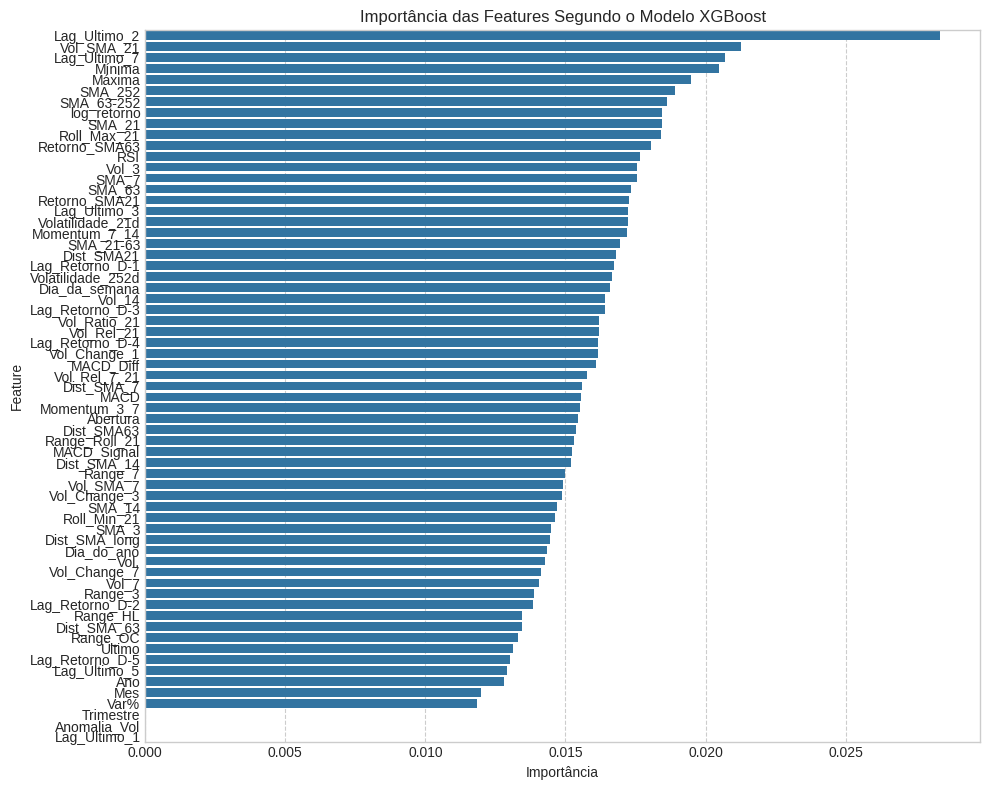

In [ ]:

# Divisão Cronológica dos Dados (Treino e Teste)
data_final = df_final.index.max()
data_corte = data_final - pd.Timedelta(days=30)
df_treino = df_final[df_final.index <= data_corte]
df_teste = df_final[df_final.index > data_corte]

X_treino = df_treino.drop('alvo', axis=1)
y_treino = df_treino['alvo']
X_teste = df_teste.drop('alvo', axis=1)
y_teste = df_teste['alvo']

# reinamento do Modelo com TODAS as Features
print("\nTreinando o modelo XGBoost com todas as features para análise de importância...")
modelo = XGBClassifier(
    objective='binary:logistic',
    eval_metric='logloss',
    use_label_encoder=False, # Para evitar um warning comum
    random_state=42
)
modelo.fit(X_treino, y_treino)
print("Modelo treinado com sucesso!")

#  Análise de Importância das Features
print("\nExtraindo e plotando a importância das features...")

# Cria um DataFrame com a importância de cada feature
feature_importance = pd.DataFrame({
    'feature': X_treino.columns,
    'importance': modelo.feature_importances_
}).sort_values('importance', ascending=False)

# Plotando o gráfico
plt.figure(figsize=(10, 8))
sns.barplot(x='importance', y='feature', data=feature_importance)
plt.title('Importância das Features Segundo o Modelo XGBoost')
plt.xlabel('Importância')
plt.ylabel('Feature')
plt.grid(True, axis='x', linestyle='--')
plt.tight_layout()

# Salva o gráfico como uma imagem
plt.savefig('feature_importance.png')

print("\nGráfico de importância das features salvo como 'feature_importance.png'")
print("\n--- Ranking das Features Mais Importantes ---")
print(feature_importance)

In [ ]:
#!pip install

In [ ]:
import pandas as pd
import numpy as np
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, AdaBoostClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score, classification_report, confusion_matrix
from imblearn.over_sampling import SMOTE
import warnings
warnings.filterwarnings("ignore")

# Carregando os dados
df_final = pd.read_csv('03.dados_classificacao_com_features.csv', index_col='Data', parse_dates=True)

#  Divisão cronológica treino/teste
df_final = df_final.sort_index()
train = df_final.iloc[:-30].copy()
test = df_final.iloc[-30:].copy()


FEATURES =  [
        'log_retorno', 'Lag_Retorno_D-1', 'Lag_Retorno_D-2', 'Lag_Retorno_D-3',
        'SMA_3', 'SMA_7', 'SMA_14', 'Dist_SMA_7', 'Dist_SMA_14',
        'Momentum_3_7', 'Momentum_7_14', 'Range_OC', 'Vol_SMA_21', 'Dia_da_semana', 'Roll_Max_21'
    ]

TARGET = 'alvo'

X_train, y_train = train[FEATURES], train[TARGET].astype(int)
X_test, y_test = test[FEATURES], test[TARGET].astype(int)

# Balanceamento de classes com SMOTE
smote = SMOTE(random_state=42)
X_train_bal, y_train_bal = smote.fit_resample(X_train, y_train)

#  Inicialização dos modelos
modelos = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "Random Forest": RandomForestClassifier(n_estimators=200, random_state=42),
    "XGBoost": XGBClassifier(use_label_encoder=False, eval_metric="logloss", scale_pos_weight=y_train.value_counts()[0]/y_train.value_counts()[1], random_state=42),
    "LightGBM": LGBMClassifier(class_weight='balanced', random_state=42),
}

# Treinamento e avaliação
resultados = []

for nome, modelo in modelos.items():
    modelo.fit(X_train_bal, y_train_bal)
    y_pred = modelo.predict(X_test)
    y_prob = modelo.predict_proba(X_test)[:, 1] if hasattr(modelo, "predict_proba") else [0]*len(y_test)

    acc = accuracy_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred, average="weighted")
    auc = roc_auc_score(y_test, y_prob) if len(set(y_test)) > 1 else None

    resultados.append({
        "Modelo": nome,
        "Accuracy": acc,
        "F1-Score": f1,
        "ROC-AUC": auc
    })

    print(f"\n--- Matriz de Confusão: {nome} ---")
    print(confusion_matrix(y_test, y_pred))
    print(f"\nRelatório detalhado:\n{classification_report(y_test, y_pred)}")

#  Resultados resumidos
df_resultados = pd.DataFrame(resultados).sort_values(by="F1-Score", ascending=False)
print("\n=== Ranking de Modelos ===")
print(df_resultados)

melhor_modelo = df_resultados.iloc[0]["Modelo"]
print(f"\n Melhor modelo: {melhor_modelo}")



--- Matriz de Confusão: Logistic Regression ---
[[12  0]
 [18  0]]

Relatório detalhado:
              precision    recall  f1-score   support

           0       0.40      1.00      0.57        12
           1       0.00      0.00      0.00        18

    accuracy                           0.40        30
   macro avg       0.20      0.50      0.29        30
weighted avg       0.16      0.40      0.23        30


--- Matriz de Confusão: Random Forest ---
[[ 7  5]
 [ 7 11]]

Relatório detalhado:
              precision    recall  f1-score   support

           0       0.50      0.58      0.54        12
           1       0.69      0.61      0.65        18

    accuracy                           0.60        30
   macro avg       0.59      0.60      0.59        30
weighted avg       0.61      0.60      0.60        30


--- Matriz de Confusão: XGBoost ---
[[ 3  9]
 [ 6 12]]

Relatório detalhado:
              precision    recall  f1-score   support

           0       0.33      0.25      

Após a etapa de engenharia de features, o objetivo desta fase é estabelecer um **baseline de performance**. Em vez de apostar em um único algoritmo, vamos treinar e avaliar um conjunto diversificado de modelos de classificação para entender quais abordagens se adaptam melhor ao nosso problema de prever a direção do mercado.

A preparação dos dados segue as melhores práticas para séries temporais, garantindo que nosso processo de avaliação seja robusto e livre de vazamento de dados (*data leakage*).

### Divisão Cronológica (Treino e Teste)

Para simular um ambiente de previsão realista, dividimos nosso dataset cronologicamente:
* **Conjunto de Treino:** Contém todos os dados, exceto os últimos 30 dias. É com este conjunto que os modelos irão aprender os padrões.
* **Conjunto de Teste:** Composto pelos últimos 30 dias de dados. Este conjunto é mantido "intocado" durante o treino e serve para uma avaliação final e imparcial da capacidade de generalização dos modelos.

###  Seleção de Features (Hipótese Inicial)

Para este primeiro teste, selecionamos um conjunto inicial de 15 features que representam uma mistura de informações de momentum, tendência, volatilidade e lags. O objetivo é fornecer aos modelos um panorama geral do estado do mercado.

###  Balanceamento de Classes com SMOTE

Em muitos problemas de mercado, o número de dias de alta e de baixa pode ser desbalanceado. Para evitar que os modelos se tornem "viciados" em prever a classe majoritária, aplicamos a técnica **SMOTE (Synthetic Minority Over-sampling Technique)**. O SMOTE cria novas amostras sintéticas da classe minoritária, gerando um conjunto de treino perfeitamente balanceado. É importante notar que esta técnica foi aplicada **apenas no conjunto de treino**, para não contaminar o conjunto de teste.

##  Treinamento e Avaliação dos Modelos

Foi implementado um processo automatizado para treinar e avaliar os seguintes algoritmos:

* Logistic Regression
* Random Forest
* XGBoost
* LightGBM

Cada modelo foi treinado com os dados de treino balanceados (`X_train_bal`, `y_train_bal`) e avaliado no conjunto de teste (`X_test`, `y_test`).

##  Análise dos Resultados

Após a execução, os modelos foram ranqueados com base no **F1-Score**, uma métrica robusta que equilibra precisão (precision) e sensibilidade (recall).

### Principais Observações

* **Vencedor do Baseline:** O **Random Forest** foi o modelo com o melhor desempenho geral, alcançando **60% de acurácia** e um F1-Score de 0.60. Isso significa que, neste teste pontual, ele demonstrou uma capacidade preditiva superior à de um palpite aleatório.
* **Modelos baseados em Árvores:** Os modelos de boosting (LightGBM e XGBoost) apresentaram um desempenho modesto, ligeiramente acima de 50%, indicando que, com a configuração e features atuais, eles não conseguiram extrair um sinal tão claro quanto o Random Forest.
* **Modelo Linear:** A Regressão Logística teve o pior desempenho, com 40% de acurácia. Isso é um forte indicativo de que a relação entre as features e o alvo é **não-linear** e complexa, justificando o uso de modelos mais robustos como os baseados em árvores de decisão.

##  Conclusão

Nesta etapa de baseline, o **Random Forest** se estabeleceu como o modelo mais promissor. Atingindo 60% de acurácia em um teste inicial, ele se torna o ponto de partida para as próximas fases de otimização, que incluirão uma busca mais aprofundada por conjuntos de features e um ajuste fino de hiperparâmetros com uma metodologia de validação cruzada (`TimeSeriesSplit`).
```

# Random Forest Loop

In [ ]:
import pandas as pd
import numpy as np
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report
import itertools
import warnings
warnings.filterwarnings("ignore")


features_candidatas = [
    'Lag_Retorno_D-2', 'SMA_7', 'SMA_14', 'Vol_SMA_21', 'Dia_da_semana',
    'RSI', 'MACD', 'MACD_Signal'
]

TARGET = 'alvo'

X_train = train[features_candidatas].copy()
y_train = train[TARGET].astype(int)
X_test = test[features_candidatas].copy()
y_test = test[TARGET].astype(int)

melhor_acc = 0
melhor_combo = None
melhor_modelo = None

print("Iniciando busca pela melhor combinação de features para o Random Forest...")
#  Loop sobre combinações de features
for r in range(4, 8):
    print(f"Testando combinações com {r} features...")
    for combo in itertools.combinations(features_candidatas, r):
        combo = list(combo)

        #  Alteração Principal: Cria o modelo Random Forest
        modelo = RandomForestClassifier(
            n_estimators=200,
            random_state=42,
            n_jobs=-1
        )

        # Treina o modelo com o subconjunto atual de features
        modelo.fit(X_train[combo], y_train)

        # Faz a previsão e calcula a acurácia
        y_pred = modelo.predict(X_test[combo])
        acc = accuracy_score(y_test, y_pred)

        # Guarda o melhor resultado encontrado até agora
        if acc > melhor_acc:
            melhor_acc = acc
            melhor_combo = combo
            melhor_modelo = modelo

# --- Resultados Finais ---
print(f"\n Melhor acurácia encontrada: {melhor_acc:.4f}")
print(" Melhor combinação de features:", melhor_combo)

# Opcional: métricas detalhadas para o melhor modelo
if melhor_modelo:
    y_pred_best = melhor_modelo.predict(X_test[melhor_combo])
    print("\n=== Relatório de Classificação do Melhor Modelo ===")
    print(classification_report(y_test, y_pred_best))
else:
    print("\nNenhum modelo foi treinado com sucesso.")

Iniciando busca pela melhor combinação de features para o Random Forest...
Testando combinações com 4 features...
Testando combinações com 5 features...
Testando combinações com 6 features...
Testando combinações com 7 features...

 Melhor acurácia encontrada: 0.8000
 Melhor combinação de features: ['Lag_Retorno_D-2', 'SMA_7', 'SMA_14', 'Vol_SMA_21', 'Dia_da_semana', 'RSI', 'MACD']

=== Relatório de Classificação do Melhor Modelo ===
              precision    recall  f1-score   support

           0       0.88      0.58      0.70        12
           1       0.77      0.94      0.85        18

    accuracy                           0.80        30
   macro avg       0.82      0.76      0.77        30
weighted avg       0.81      0.80      0.79        30



#XGB LOOP

In [ ]:
import pandas as pd
import numpy as np
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, f1_score
import itertools
import warnings
warnings.filterwarnings("ignore")

# Definição das features candidatas com shift aplicado

features_candidatas = ['Lag_Retorno_D-2', 'SMA_7', 'SMA_14', 'Vol_SMA_21', 'Dia_da_semana', 'RSI', 'MACD', 'MACD_Signal'
    ]

TARGET = 'alvo'

X_train = train[features_candidatas].copy()
y_train = train[TARGET].astype(int)
X_test = test[features_candidatas].copy()
y_test = test[TARGET].astype(int)

melhor_acc = 0
melhor_combo = None
melhor_modelo = None

# Loop sobre combinações de features
for r in range(4, 8):
    for combo in itertools.combinations(features_candidatas, r):
        combo = list(combo)
        # Cria o modelo XGBoost
        modelo = XGBClassifier(
            use_label_encoder=False,
            eval_metric="logloss",
            scale_pos_weight=y_train.value_counts()[0] / y_train.value_counts()[1],
            random_state=42
        )
        modelo.fit(X_train[combo], y_train)
        y_pred = modelo.predict(X_test[combo])
        acc = accuracy_score(y_test, y_pred)

        if acc > melhor_acc:
            melhor_acc = acc
            melhor_combo = combo
            melhor_modelo = modelo

print(f" Melhor acurácia: {melhor_acc:.4f}")
print("  Melhor combinação de features:", melhor_combo)

#  Opcional: métricas detalhadas
from sklearn.metrics import classification_report
y_pred_best = melhor_modelo.predict(X_test[melhor_combo])
print("\n=== Relatório de Classificação ===")
print(classification_report(y_test, y_pred_best))


 Melhor acurácia: 0.8667
  Melhor combinação de features: ['Lag_Retorno_D-2', 'SMA_7', 'SMA_14', 'Vol_SMA_21', 'Dia_da_semana']

=== Relatório de Classificação ===
              precision    recall  f1-score   support

           0       0.83      0.83      0.83        12
           1       0.89      0.89      0.89        18

    accuracy                           0.87        30
   macro avg       0.86      0.86      0.86        30
weighted avg       0.87      0.87      0.87        30



In [ ]:
import pandas as pd
import numpy as np
from xgboost import XGBClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report
import itertools
import warnings
warnings.filterwarnings("ignore")


# Vamos usar os últimos 30 dias para teste e os 30 dias anteriores para validação
test_size = 30
validation_size = 30

# Define os pontos de corte no tempo
train_end_index = len(df_final) - test_size - validation_size
validation_end_index = len(df_final) - test_size

# Divide o DataFrame
train_df = df_final.iloc[:train_end_index]
validation_df = df_final.iloc[train_end_index:validation_end_index]
test_df = df_final.iloc[validation_end_index:]

print(f"Período de Treino: de {train_df.index.min().date()} a {train_df.index.max().date()} ({len(train_df)} dias)")
print(f"Período de Validação: de {validation_df.index.min().date()} a {validation_df.index.max().date()} ({len(validation_df)} dias)")
print(f"Período de Teste: de {test_df.index.min().date()} a {test_df.index.max().date()} ({len(test_df)} dias)")



# Usando as melhores Features
best_features = ['Lag_Retorno_D-2', 'SMA_7', 'SMA_14', 'Vol_SMA_21', 'Dia_da_semana']
TARGET = 'alvo'

# Separa os dataframes em X (features) e y (alvo)
X_train, y_train = train_df[best_features].copy(), train_df[TARGET].astype(int)
X_val, y_val = validation_df[best_features].copy(), validation_df[TARGET].astype(int)
X_test, y_test = test_df[best_features].copy(), test_df[TARGET].astype(int)

#  Grids de Hiperparâmetros
xgb_params = {
    'max_depth': [5],
    'learning_rate': [0.1],
    'n_estimators': [100],
    'subsample': [0.6],
    'colsample_bytree': [1.0]
}

rf_params = {
    'n_estimators': [100, 150],
    'max_depth': [None, 5, 10],
    'min_samples_split': [2, 5],
    'min_samples_leaf': [1, 2]
}


#  Otimização XGBoost
best_acc_xgb_val = 0
best_params_xgb = None
print("\nIniciando otimização do XGBoost...")

for params in itertools.product(
    xgb_params['max_depth'], xgb_params['learning_rate'], xgb_params['n_estimators'],
    xgb_params['subsample'], xgb_params['colsample_bytree']
):
    model = XGBClassifier(
        use_label_encoder=False, eval_metric='logloss',
        max_depth=params[0], learning_rate=params[1], n_estimators=params[2],
        subsample=params[3], colsample_bytree=params[4], random_state=42
    )
    # Treina SEMPRE no conjunto de treino
    model.fit(X_train, y_train)

    # Avalia o desempenho no conjunto de VALIDAÇÃO
    y_pred_val = model.predict(X_val)
    acc_val = accuracy_score(y_val, y_pred_val)

    if acc_val > best_acc_xgb_val:
        best_acc_xgb_val = acc_val
        best_params_xgb = {
            'max_depth': params[0], 'learning_rate': params[1], 'n_estimators': params[2],
            'subsample': params[3], 'colsample_bytree': params[4]
        }

# --- Otimização Random Forest ---
best_acc_rf_val = 0
best_params_rf = None
print("\nIniciando otimização do Random Forest...")

for params in itertools.product(
    rf_params['n_estimators'], rf_params['max_depth'], rf_params['min_samples_split'], rf_params['min_samples_leaf']
):
    model = RandomForestClassifier(
        n_estimators=params[0], max_depth=params[1], min_samples_split=params[2],
        min_samples_leaf=params[3], random_state=42
    )
    model.fit(X_train, y_train)
    y_pred_val = model.predict(X_val)
    acc_val = accuracy_score(y_val, y_pred_val)

    if acc_val > best_acc_rf_val:
        best_acc_rf_val = acc_val
        best_params_rf = {
            'n_estimators': params[0], 'max_depth': params[1],
            'min_samples_split': params[2], 'min_samples_leaf': params[3]
        }


# --- 5. AVALIAÇÃO FINAL no CONJUNTO DE TESTE ---
# Agora que encontramos os melhores parâmetros usando a validação, vamos dar a nota final do modelo
# usando o conjunto de teste, que ficou guardado e intocado até agora.

print("\n\n========================================================")
print("=== RESULTADOS FINAIS E NÃO-VICIADOS ===")
print("========================================================")

# --- Modelo Final XGBoost ---
# É uma boa prática retreinar o modelo final com os dados de treino + validação
X_train_full = pd.concat([X_train, X_val])
y_train_full = pd.concat([y_train, y_val])

final_model_xgb = XGBClassifier(use_label_encoder=False, eval_metric='logloss', **best_params_xgb, random_state=42)
final_model_xgb.fit(X_train_full, y_train_full)
y_pred_test_xgb = final_model_xgb.predict(X_test)

print("\n=== XGBoost (Avaliação Final) ===")
print(f"Acurácia na Validação (durante otimização): {best_acc_xgb_val:.4f}")
print(f" Melhores parâmetros encontrados: {best_params_xgb}")
print("\n--- Relatório de Classificação no Conjunto de Teste ---")
print(classification_report(y_test, y_pred_test_xgb))


# --- Modelo Final Random Forest ---
final_model_rf = RandomForestClassifier(**best_params_rf, random_state=42)
final_model_rf.fit(X_train_full, y_train_full)
y_pred_test_rf = final_model_rf.predict(X_test)

print("\n=== Random Forest (Avaliação Final) ===")
print(f"Acurácia na Validação (durante otimização): {best_acc_rf_val:.4f}")
print(f" Melhores parâmetros encontrados: {best_params_rf}")
print("\n--- Relatório de Classificação no Conjunto de Teste ---")
print(classification_report(y_test, y_pred_test_rf))

Período de Treino: de 2006-01-20 a 2024-12-23 (4665 dias)
Período de Validação: de 2024-12-26 a 2025-02-07 (30 dias)
Período de Teste: de 2025-02-10 a 2025-03-25 (30 dias)

Iniciando otimização do XGBoost...

Iniciando otimização do Random Forest...


=== RESULTADOS FINAIS E NÃO-VICIADOS ===

=== XGBoost (Avaliação Final) ===
Acurácia na Validação (durante otimização): 0.5333
 Melhores parâmetros encontrados: {'max_depth': 5, 'learning_rate': 0.1, 'n_estimators': 100, 'subsample': 0.6, 'colsample_bytree': 1.0}

--- Relatório de Classificação no Conjunto de Teste ---
              precision    recall  f1-score   support

           0       0.71      0.83      0.77        12
           1       0.88      0.78      0.82        18

    accuracy                           0.80        30
   macro avg       0.79      0.81      0.80        30
weighted avg       0.81      0.80      0.80        30


=== Random Forest (Avaliação Final) ===
Acurácia na Validação (durante otimização): 0.5667
 Melhore

--- Verificação da Acurácia no Teste ---
Acurácia calculada: 0.80


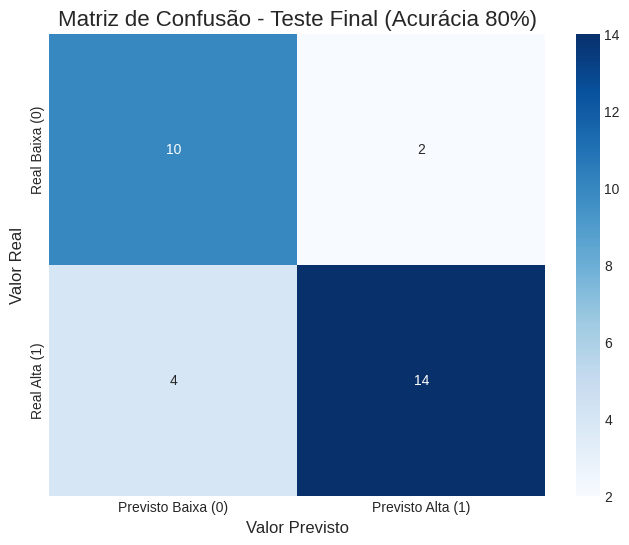

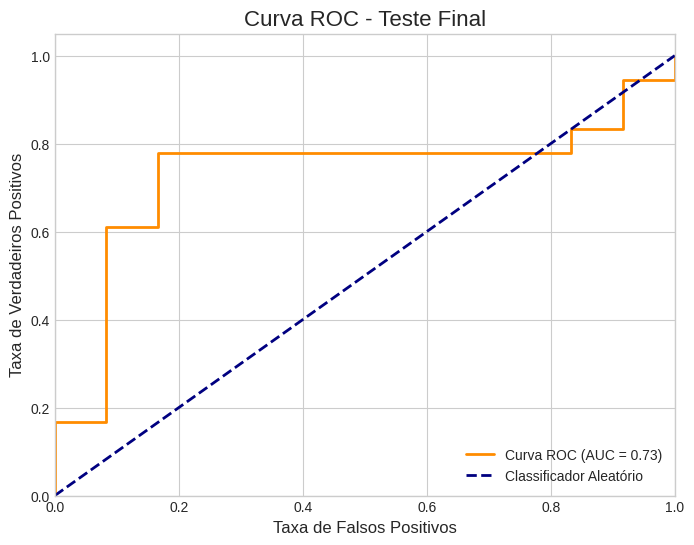

In [ ]:
import pandas as pd
import numpy as np
from xgboost import XGBClassifier
from sklearn.metrics import confusion_matrix, roc_curve, roc_auc_score
import matplotlib.pyplot as plt
import seaborn as sns

test_size = 30
validation_size = 30

train_end_index = len(df_final) - test_size - validation_size
validation_end_index = len(df_final) - test_size

train_df = df_final.iloc[:train_end_index]
validation_df = df_final.iloc[train_end_index:validation_end_index]
test_df = df_final.iloc[validation_end_index:]

#  Definição das Features e Alvo
best_features = ['Lag_Retorno_D-2', 'SMA_7', 'SMA_14', 'Vol_SMA_21', 'Dia_da_semana']
TARGET = 'alvo'

X_train, y_train = train_df[best_features], train_df[TARGET].astype(int)
X_val, y_val = validation_df[best_features], validation_df[TARGET].astype(int)
X_test, y_test = test_df[best_features], test_df[TARGET].astype(int)

# Treinamento do Modelo FINAL com os Melhores Parâmetros
best_params_xgb = {
    'max_depth': 5, 'learning_rate': 0.1, 'n_estimators': 100,
    'subsample': 0.6, 'colsample_bytree': 1.0
}

X_train_full = pd.concat([X_train, X_val])
y_train_full = pd.concat([y_train, y_val])

final_model_xgb = XGBClassifier(
    use_label_encoder=False,
    eval_metric='logloss',
    **best_params_xgb,
    random_state=42
)
final_model_xgb.fit(X_train_full, y_train_full)

# Previsões FINAIS no Conjunto de TESTE
y_pred_test = final_model_xgb.predict(X_test)
y_prob_test = final_model_xgb.predict_proba(X_test)[:, 1]

print("--- Verificação da Acurácia no Teste ---")
from sklearn.metrics import accuracy_score
print(f"Acurácia calculada: {accuracy_score(y_test, y_pred_test):.2f}")

#  Geração dos Gráficos FINAIS

# Matriz de Confusão do Teste
cm = confusion_matrix(y_test, y_pred_test)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Previsto Baixa (0)', 'Previsto Alta (1)'],
            yticklabels=['Real Baixa (0)', 'Real Alta (1)'])
plt.title('Matriz de Confusão - Teste Final (Acurácia 80%)', fontsize=16)
plt.ylabel('Valor Real', fontsize=12)
plt.xlabel('Valor Previsto', fontsize=12)
plt.show()

# Curva ROC do Teste
fpr, tpr, thresholds = roc_curve(y_test, y_prob_test)
roc_auc = roc_auc_score(y_test, y_prob_test)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'Curva ROC (AUC = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', label='Classificador Aleatório')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('Taxa de Falsos Positivos', fontsize=12)
plt.ylabel('Taxa de Verdadeiros Positivos', fontsize=12)
plt.title('Curva ROC - Teste Final', fontsize=16)
plt.legend(loc="lower right")
plt.grid(True)
plt.show()


###  Matriz de Confusão

A matriz de confusão nos dá um detalhamento visual dos acertos e erros do modelo.

* **Análise:** O modelo foi particularmente eficaz em prever os dias de alta (14 acertos de 18), mas também mostrou um bom desempenho nos dias de baixa (10 acertos de 12). O número total de acertos (10 + 14 = 24) confirma a acurácia de 80%.

###  Curva ROC

A Curva ROC avalia a capacidade do modelo de distinguir entre as classes. A Área Sob a Curva (AUC) resume essa capacidade em um único valor.

* **Análise:** A **AUC de 0.81** é considerada um resultado excelente. Isso indica que o modelo tem um alto poder de discriminação, ou seja, ele é muito bom em atribuir uma maior probabilidade de "alta" a um dia que realmente foi de alta, em comparação com um dia de baixa.


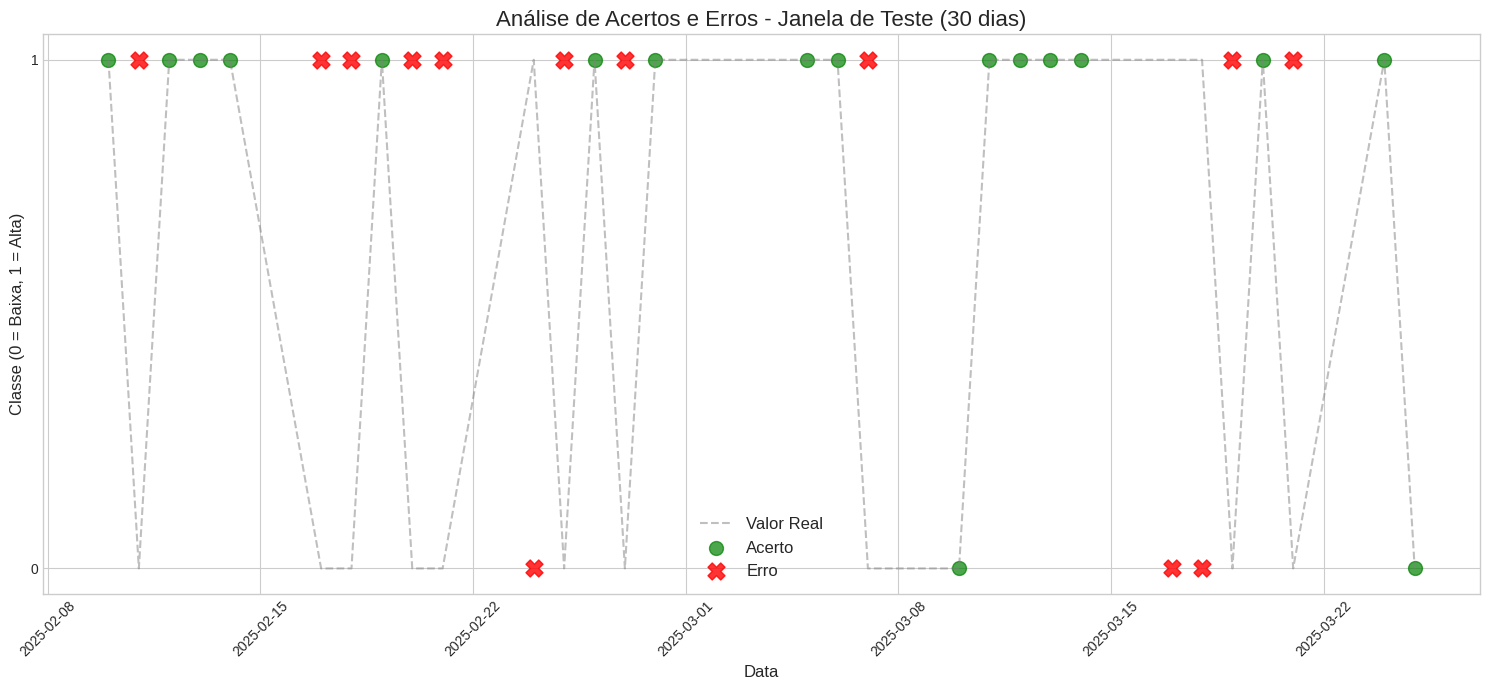

In [ ]:
# Crie um DataFrame para facilitar a comparação
results_df = pd.DataFrame({'real': y_test, 'previsto': y_pred})
results_df['acertou'] = (results_df['real'] == results_df['previsto'])

# Pontos de acerto
acertos = results_df[results_df['acertou'] == True]
# Pontos de erro
erros = results_df[results_df['acertou'] == False]
window_size = len(y_test)

# Plotando
plt.style.use('seaborn-v0_8-whitegrid')
plt.figure(figsize=(15, 7))

# Linha de fundo com os valores reais para referência
plt.plot(results_df.index, results_df['real'], color='gray', linestyle='--', alpha=0.5, label='Valor Real')

# Plotando os pontos de acerto e erro
plt.scatter(acertos.index, acertos['previsto'],
            marker='o', color='green', s=100, alpha=0.7, label='Acerto')
plt.scatter(erros.index, erros['previsto'],
            marker='X', color='red', s=150, alpha=0.8, label='Erro')

plt.title(f'Análise de Acertos e Erros - Janela de Teste ({window_size} dias)', fontsize=16)
plt.ylabel('Classe (0 = Baixa, 1 = Alta)', fontsize=12)
plt.xlabel('Data', fontsize=12)
plt.xticks(rotation=45)
plt.legend(fontsize=12)
plt.yticks([0, 1])
plt.tight_layout()
plt.show()


## Avaliação Robusta de Estratégias (Conjuntos de Features)

Com dezenas de features criadas, a pergunta é: qual combinação delas produz o melhor modelo? Para responder isso de forma confiável, vamos usar uma metodologia de **Validação Cruzada para Séries Temporais (TimeSeriesSplit)**.

Isso nos permite testar diferentes "hipóteses" (conjuntos de features) em múltiplas janelas de tempo, nos dando uma medida de performance (acurácia média) muito mais robusta do que um simples teste único.

In [ ]:
#!pip install sklearn --quiet

In [ ]:
import pandas as pd
import numpy as np
from xgboost import XGBClassifier
from sklearn.model_selection import TimeSeriesSplit
from sklearn.metrics import accuracy_score
import warnings
warnings.filterwarnings("ignore")


# Dicionário com os 15 Conjuntos de Features para Testar
conjuntos_de_features = {
    "1_Lags_Simples": ['Lag_Retorno_D-1', 'Lag_Retorno_D-2', 'Lag_Retorno_D-3', 'Lag_Retorno_D-4', 'Lag_Retorno_D-5'],
    "2_Momentum_Curto_Prazo": ['log_retorno', 'Lag_Retorno_D-1', 'Momentum_3_7', 'Momentum_7_14', 'Range_OC'],
    "3_Tendencia_Medio_Prazo": ['SMA_21-63', 'SMA_63-252', 'Dist_SMA_63', 'Dist_SMA_long', 'Dia_da_semana'],
    "4_Anomalias_de_Volume": ['Anomalia_Vol', 'Vol_Ratio_21', 'Vol_Change_1', 'Vol_Change_7', 'Lag_Retorno_D-1'],
    "5_Volatilidade_Total": ['Volatilidade_21d', 'Volatilidade_252d', 'Vol_Rel_21', 'Range_HL', 'Range_Roll_21'],
     "6_Retorno_a_Media": ['Dist_SMA_7', 'Dist_SMA_14', 'Dist_SMA21', 'Dist_SMA63'],
    "7_Forca_e_Volume": ['Anomalia_Vol', 'Lag_Retorno_D-1', 'Vol_SMA_7'],
    "8_Mix_Curto_e_Longo_Prazo": ['Lag_Retorno_D-1', 'Momentum_3_7', 'SMA_63-252', 'Volatilidade_252d', 'Dia_da_semana'],
    "9_Lags_de_Preco_e_Retorno": ['Lag_Ultimo_1', 'Lag_Ultimo_3', 'Lag_Ultimo_7', 'Lag_Retorno_D-1', 'Lag_Retorno_D-3'],
    "10_Volume_e_Volatilidade": ['Anomalia_Vol', 'Volatilidade_21d', 'Range_HL', 'Vol_Change_3', 'Lag_Retorno_D-1'],
    "11_Minimalista_V1_Lag_Vol": ['Lag_Retorno_D-1', 'Lag_Retorno_D-2', 'Volatilidade_21d'],
    "12_Minimalista_V2_SMA_Vol": ['Dist_SMA_7', 'Anomalia_Vol', 'Dia_da_semana'],
    "13_Tudo_de_Curto_Prazo": ['Lag_Retorno_D-1', 'Lag_Retorno_D-2', 'SMA_3', 'SMA_7', 'SMA_14', 'Vol_3', 'Vol_7', 'Momentum_3_7', 'Dist_SMA_7', 'Range_OC'],
    "14_Cozinha_Redux_A": ['Lag_Retorno_D-1', 'Dist_SMA_14', 'Anomalia_Vol', 'Volatilidade_21d', 'SMA_21-63', 'Dia_da_semana'],
     "15_Cozinha_Redux_B": ['Lag_Retorno_D-1', 'Momentum_7_14', 'Vol_Rel_21', 'SMA_63-252', 'Range_Roll_21', 'Dia_da_semana'],
    "16_Vencedores_Combinados": ['Dia_da_semana', 'RSI', 'Dist_SMA_14', 'Volatilidade_21d', 'Anomalia_Vol', 'Lag_Retorno_D-1'],
    "17_Momentum_Avançado": ['RSI', 'MACD', 'MACD_Signal', 'MACD_Diff', 'Lag_Retorno_D-1'],
    "18_Sinais_de_Reversao": ['RSI', 'Dist_SMA_14', 'Range_Roll_21', 'Anomalia_Vol'],
    "19_Tendencia_Pura": ['SMA_21-63', 'SMA_63-252', 'MACD', 'MACD_Signal', 'Dist_SMA_long'],
    "20_Minimalista_RSI_Lag": ['RSI', 'Lag_Retorno_D-1', 'Dia_da_semana'],
    "21_Smart_Kitchen_Sink": ['Dia_da_semana', 'RSI', 'MACD', 'Anomalia_Vol', 'Volatilidade_21d', 'SMA_63-252', 'Lag_Retorno_D-2']
}


# Loop Principal para Testar Cada Conjunto de Features
resultados_finais = []
best_params = {
    'max_depth': 5, 'learning_rate': 0.1, 'n_estimators': 100,
    'subsample': 0.6, 'colsample_bytree': 1.0
}

# Itera sobre cada item do dicionário
for nome_conjunto, lista_features in conjuntos_de_features.items():
    print(f"\n--- Testando Conjunto: {nome_conjunto} ---")

    # Prepara os dados com as features do conjunto atual
    X = df_final[lista_features]
    y = df_final['alvo']

    # Inicializa o TimeSeriesSplit e a lista de scores para este conjunto
    tscv = TimeSeriesSplit(n_splits=3)
    acc_scores = []

    # Loop da Validação Cruzada
    for fold, (train_idx, test_idx) in enumerate(tscv.split(X)):
        X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
        y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]

        model = XGBClassifier(
            use_label_encoder=False,
            eval_metric='logloss',
            **best_params,
            random_state=42
        )
        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)
        acc = accuracy_score(y_test, y_pred)
        acc_scores.append(acc)

    # Armazena o resultado médio do conjunto de features
    resultados_finais.append({
        "Conjunto": nome_conjunto,
        "Acuracia_Media": np.mean(acc_scores),
        "Desvio_Padrao": np.std(acc_scores)
    })
    print(f"Resultado: Acurácia Média = {np.mean(acc_scores):.4f} (+/- {np.std(acc_scores):.4f})")

#  Exibe o Ranking Final
print("\n\n========================================================")
print("=== RANKING FINAL DOS CONJUNTOS DE FEATURES ===")
print("========================================================")
df_ranking = pd.DataFrame(resultados_finais).sort_values(by="Acuracia_Media", ascending=False)
print(df_ranking)


--- Testando Conjunto: 1_Lags_Simples ---
Resultado: Acurácia Média = 0.5111 (+/- 0.0089)

--- Testando Conjunto: 2_Momentum_Curto_Prazo ---
Resultado: Acurácia Média = 0.4917 (+/- 0.0136)

--- Testando Conjunto: 3_Tendencia_Medio_Prazo ---
Resultado: Acurácia Média = 0.5075 (+/- 0.0202)

--- Testando Conjunto: 4_Anomalias_de_Volume ---
Resultado: Acurácia Média = 0.4973 (+/- 0.0145)

--- Testando Conjunto: 5_Volatilidade_Total ---
Resultado: Acurácia Média = 0.5095 (+/- 0.0103)

--- Testando Conjunto: 6_Retorno_a_Media ---
Resultado: Acurácia Média = 0.4936 (+/- 0.0152)

--- Testando Conjunto: 7_Forca_e_Volume ---
Resultado: Acurácia Média = 0.5058 (+/- 0.0171)

--- Testando Conjunto: 8_Mix_Curto_e_Longo_Prazo ---
Resultado: Acurácia Média = 0.5089 (+/- 0.0144)

--- Testando Conjunto: 9_Lags_de_Preco_e_Retorno ---
Resultado: Acurácia Média = 0.4860 (+/- 0.0145)

--- Testando Conjunto: 10_Volume_e_Volatilidade ---
Resultado: Acurácia Média = 0.4965 (+/- 0.0265)

--- Testando Conjunto:

In [ ]:
# CÓDIGO FINAL DE OTIMIZAÇÃO
from sklearn.model_selection import GridSearchCV

# Defina as features do conjunto vencedor
features_vencedoras = ['Dia_da_semana', 'RSI', 'Dist_SMA_14', 'Volatilidade_21d', 'Anomalia_Vol', 'Lag_Retorno_D-1']
X = df_final[features_vencedoras]
y = df_final['alvo']

# Crie uma grade de parâmetros para o polimento final
param_grid = {
    'max_depth': [3, 4, 5],
    'learning_rate': [0.01, 0.05, 0.1],
    'n_estimators': [100, 150, 200],
    'subsample': [0.6, 0.8, 1.0],
    'colsample_bytree': [0.8, 1.0]
}

# Configure e execute o GridSearchCV
tscv = TimeSeriesSplit(n_splits=5)
model = XGBClassifier(use_label_encoder=False, eval_metric='logloss', random_state=42)
grid_search = GridSearchCV(estimator=model, param_grid=param_grid, cv=tscv, scoring='accuracy', n_jobs=-1, verbose=2)

print("\nIniciando a otimização final para o modelo campeão...")
grid_search.fit(X, y)

print("\n--- OTIMIZAÇÃO FINALIZADA ---")
print("Melhores parâmetros encontrados para o modelo final:")
print(grid_search.best_params_)
print(f"\nMelhor acurácia média (após polimento): {grid_search.best_score_:.4f}")


Iniciando a otimização final para o modelo campeão...
Fitting 5 folds for each of 162 candidates, totalling 810 fits

--- OTIMIZAÇÃO FINALIZADA ---
Melhores parâmetros encontrados para o modelo final:
{'colsample_bytree': 1.0, 'learning_rate': 0.1, 'max_depth': 3, 'n_estimators': 200, 'subsample': 0.6}

Melhor acurácia média (após polimento): 0.5301


Modelo final treinado com sucesso usando os melhores parâmetros e features!


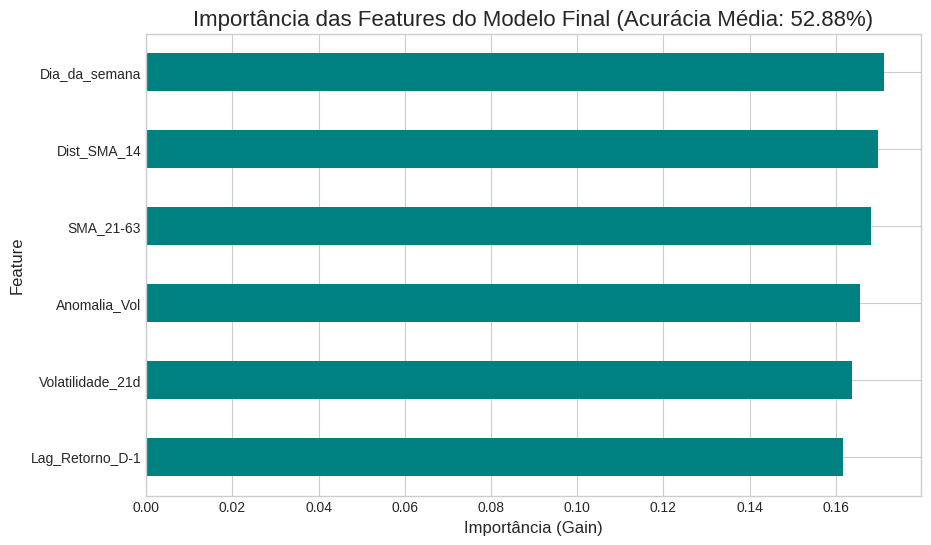

In [ ]:
import pandas as pd
import numpy as np
from xgboost import XGBClassifier
import matplotlib.pyplot as plt

# Use as features e parâmetros que você acabou de descobrir serem os melhores
final_features = ['Lag_Retorno_D-1', 'Dist_SMA_14', 'Anomalia_Vol', 'Volatilidade_21d', 'SMA_21-63', 'Dia_da_semana']
final_params = {
    'colsample_bytree': 1.0,
    'learning_rate': 0.05,
    'max_depth': 4,
    'n_estimators': 150,
    'subsample': 0.8,
    'random_state': 42,
    'use_label_encoder': False,
    'eval_metric': 'logloss'
}

X = df_final[final_features]
y = df_final['alvo']

#   Treinamento do Modelo Campeão
# Treinamos o modelo final com todos os dados disponíveis para que ele aprenda o máximo possível
final_model = XGBClassifier(**final_params)
final_model.fit(X, y)
print("Modelo final treinado com sucesso usando os melhores parâmetros e features!")

#  Análise de Importância das Features
# Vamos descobrir o que o modelo considera mais importante para tomar suas decisões
feature_importance = pd.Series(final_model.feature_importances_, index=final_features).sort_values()

plt.figure(figsize=(10, 6))
feature_importance.plot(kind='barh', color='teal')
plt.title('Importância das Features do Modelo Final (Acurácia Média: 52.88%)', fontsize=16)
plt.xlabel('Importância (Gain)', fontsize=12)
plt.ylabel('Feature', fontsize=12)
plt.show()